In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_excel(r"C:\Users\hp\OneDrive\Desktop\Retail-Analytics-Platform\Data\raw.xlsx")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# EDA

## Data Profiling

In [4]:
df.shape

(51290, 24)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  str           
 10  State           51290 non-null  str           
 11  Country         51290 non-null  str           
 12  Region          51290 non-null  str           
 13  Market          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Category     

In [6]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2014-05-11 21:26:49.155780,2014-05-15 20:42:42.745174,55190.379428,246.490581,3.476545,0.142908,28.610982,26.478567
min,1.00000,2012-01-01 00:00:00,2012-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.002000
25%,12823.25000,2013-06-19 00:00:00,2013-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2014-07-08 00:00:00,2014-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2015-05-22 00:00:00,2015-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2015-12-31 00:00:00,2016-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.251373


In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')

In [8]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Postal Code    41296
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

Postal Code    80.51472
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique().sort_values()

Segment               3
Category              3
Ship Mode             4
Order Priority        4
Market                5
Quantity             14
Sub-Category         17
Region               23
Discount             29
Country             165
Postal Code         631
Customer Name       796
State              1102
Order Date         1430
Ship Date          1464
City               3650
Product Name       3788
Product ID         3788
Shipping Cost     16753
Customer ID       17415
Order ID          25728
Sales             27200
Profit            28234
Row ID            51290
dtype: int64

#### EDA Summary

In [12]:
eda_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": df.isnull().sum() / len(df) * 100,
    "Unique Values": df.nunique()})
eda_summary

,Data Type,Missing Values,Missing %,Unique Values
Row ID,int64,0,0.00000,51290
Order ID,str,0,0.00000,25728
Order Date,datetime64[us],0,0.00000,1430
Ship Date,datetime64[us],0,0.00000,1464
Ship Mode,str,0,0.00000,4
Customer ID,str,0,0.00000,17415
Customer Name,str,0,0.00000,796
Segment,str,0,0.00000,3
Postal Code,float64,41296,80.51472,631
City,str,0,0.00000,3650


## Data Qualitiy Investigation

In [13]:
df[df["Postal Code"].isna()][["City", "State", "Country", "Region", "Market"]].head(20)

,City,State,Country,Region,Market
1,Wollongong,New South Wales,Australia,Oceania,Asia Pacific
2,Brisbane,Queensland,Australia,Oceania,Asia Pacific
3,Berlin,Berlin,Germany,Western Europe,Europe
4,Dakar,Dakar,Senegal,Western Africa,Africa
5,Sydney,New South Wales,Australia,Oceania,Asia Pacific
6,Porirua,Wellington,New Zealand,Oceania,Asia Pacific
7,Hamilton,Waikato,New Zealand,Oceania,Asia Pacific
11,Kabul,Kabul,Afghanistan,Southern Asia,Asia Pacific
12,Jizan,Jizan,Saudi Arabia,Western Asia,Asia Pacific
13,Toledo,Parana,Brazil,South America,LATAM


In [14]:
df[df["Postal Code"].isna()]["Country"].value_counts().head(20)

Country
Australia             2837
France                2827
Mexico                2635
Germany               2063
China                 1880
United Kingdom        1633
Brazil                1593
India                 1554
Indonesia             1390
Turkey                1378
Italy                 1100
Nigeria                905
Spain                  859
Dominican Republic     742
El Salvador            736
Cuba                   724
Honduras               713
Philippines            681
New Zealand            628
Nicaragua              614
Name: count, dtype: int64

In [15]:
city_postal = (df[df["Postal Code"].notna()].groupby(["Country", "City"])["Postal Code"].nunique().sort_values(ascending=False))
city_postal.head(20)

Country        City         
United States  Los Angeles      6
               Columbia         4
               Houston          4
               New York City    4
               Philadelphia     4
               Springfield      4
               Fairfield        3
               Detroit          3
               Franklin         3
               Burlington       3
               Florence         3
               Columbus         3
               Concord          3
               Miami            3
               Dallas           3
               Chicago          3
               Lakewood         3
               Lancaster        3
               Auburn           3
               Jackson          3
Name: Postal Code, dtype: int64

In [16]:
(df["Ship Date"] < df["Order Date"]).sum()

np.int64(0)

In [17]:
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [18]:
df["Shipping_Days"].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Shipping_Days, dtype: float64

In [19]:
df["Shipping_Days"].value_counts().sort_index()

Shipping_Days
0     2600
1     1662
2     7026
3     5035
4    14434
5    11221
6     6255
7     3057
Name: count, dtype: int64

In [20]:
df["Order ID"].duplicated().sum()

np.int64(25562)

In [21]:
df["Order ID"].nunique()

25728

In [22]:
df["Customer ID"].nunique()

17415

In [23]:
df["Product ID"].nunique()

3788

In [24]:
print("Negative Sales:", (df["Sales"] < 0).sum())
print("Zero Sales:", (df["Sales"] == 0).sum())
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Discount < 0:", (df["Discount"] < 0).sum())
print("Discount > 1:", (df["Discount"] > 1).sum())
print("Shipping Cost < 0:", (df["Shipping Cost"] < 0).sum())

Negative Sales: 0
Zero Sales: 0
Negative Quantity: 0
Zero Quantity: 0
Discount < 0: 0
Discount > 1: 0
Shipping Cost < 0: 0


In [25]:
df["Discount"].value_counts().sort_index()

Discount
0.000    29009
0.002      461
0.070      150
0.100     4068
0.150      459
0.150       82
0.170      735
0.200     4998
0.202       41
0.250      198
0.270      388
0.300      340
0.320       27
0.350      122
0.370       74
0.400     3177
0.402      104
0.450        2
0.450      325
0.470      725
0.500     1633
0.550       10
0.570       12
0.600     2006
0.602       23
0.650       17
0.700     1786
0.800      316
0.850        2
Name: count, dtype: int64

In [26]:
df["Discount"].describe()

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: Discount, dtype: float64

In [27]:
postal_mapping = (df[df["Postal Code"].notna()].groupby(["Country", "City"])["Postal Code"].nunique())
safe_locations = postal_mapping[postal_mapping == 1]
len(safe_locations)

463

In [28]:
len(df[df["Postal Code"].isna() & df.set_index(["Country", "City"]).index.isin(safe_locations.index)])

0

In [29]:
df[df["Order ID"].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping_Days


In [30]:
df.duplicated(subset=["Order ID","Product ID","Customer ID","Sales","Quantity","Discount","Profit"]).sum()

np.int64(10)

In [31]:
df[df.duplicated(subset=[
        "Order ID",
        "Product ID",
        "Customer ID",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"],keep=False)].sort_values("Order ID").head(50)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping_Days
30153,44647,AG-2015-CD27903-42236,2015-08-20,2015-08-25,Standard Class,CD-27903,Cynthia Delaney,Home Office,NaN,Oran,...,Technology,Accessories,"Memorex Mouse, USB",56.760,2,0.00,10.7400,5.430,High,5
37874,44649,AG-2015-CD27903-42236,2015-08-20,2015-08-25,Standard Class,CD-27903,Cynthia Delaney,Home Office,NaN,Oran,...,Technology,Accessories,"Memorex Mouse, USB",56.760,2,0.00,10.7400,2.770,High,5
37103,13944,ES-2013-RF1984014-41515,2013-08-29,2013-09-05,Standard Class,RF-1984014,Roy Französisch,Consumer,NaN,Mechelen,...,Office Supplies,Art,"Sanford Pens, Fluorescent",37.080,3,0.00,10.3500,2.980,Medium,7
43214,13946,ES-2013-RF1984014-41515,2013-08-29,2013-09-05,Standard Class,RF-1984014,Roy Französisch,Consumer,NaN,Mechelen,...,Office Supplies,Art,"Sanford Pens, Fluorescent",37.080,3,0.00,10.3500,1.840,Medium,7
34100,10449,ES-2014-SR20740120-41804,2014-06-14,2014-06-21,Standard Class,SR-20740120,Steven Roelle,Home Office,NaN,Madrid,...,Office Supplies,Binders,"Wilson Jones 3-Hole Punch, Economy",83.970,3,0.00,27.6300,3.880,Medium,7
36524,10446,ES-2014-SR20740120-41804,2014-06-14,2014-06-21,Standard Class,SR-20740120,Steven Roelle,Home Office,NaN,Madrid,...,Office Supplies,Binders,"Wilson Jones 3-Hole Punch, Economy",83.970,3,0.00,27.6300,3.140,Medium,7
44705,27443,ID-2012-AR105107-41031,2012-05-02,2012-05-08,Standard Class,AR-105107,Andrew Roberts,Consumer,NaN,Armidale,...,Office Supplies,Binders,"Cardinal Hole Reinforcements, Recycled",15.390,3,0.10,2.5200,1.700,Medium,6
45322,27445,ID-2012-AR105107-41031,2012-05-02,2012-05-08,Standard Class,AR-105107,Andrew Roberts,Consumer,NaN,Armidale,...,Office Supplies,Binders,"Cardinal Hole Reinforcements, Recycled",15.390,3,0.10,2.5200,1.640,Medium,6
4492,29853,IN-2013-RM19375130-41583,2013-11-05,2013-11-06,First Class,RM-19375130,Raymond Messe,Consumer,NaN,Bangkok,...,Furniture,Chairs,"Office Star Steel Folding Chair, Adjustable",343.830,5,0.27,89.4300,72.950,Medium,1
6056,29854,IN-2013-RM19375130-41583,2013-11-05,2013-11-06,First Class,RM-19375130,Raymond Messe,Consumer,NaN,Bangkok,...,Furniture,Chairs,"Office Star Steel Folding Chair, Adjustable",343.830,5,0.27,89.4300,55.800,Medium,1


In [32]:
duplicate_subset = [
    "Order ID",
    "Product ID",
    "Customer ID",
    "Sales",
    "Quantity",
    "Discount",
    "Profit"]
duplicates = df[df.duplicated(subset=duplicate_subset, keep=False)].sort_values("Order ID")
duplicates

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping_Days
30153,44647,AG-2015-CD27903-42236,2015-08-20,2015-08-25,Standard Class,CD-27903,Cynthia Delaney,Home Office,NaN,Oran,...,Technology,Accessories,"Memorex Mouse, USB",56.760,2,0.00,10.7400,5.430,High,5
37874,44649,AG-2015-CD27903-42236,2015-08-20,2015-08-25,Standard Class,CD-27903,Cynthia Delaney,Home Office,NaN,Oran,...,Technology,Accessories,"Memorex Mouse, USB",56.760,2,0.00,10.7400,2.770,High,5
37103,13944,ES-2013-RF1984014-41515,2013-08-29,2013-09-05,Standard Class,RF-1984014,Roy Französisch,Consumer,NaN,Mechelen,...,Office Supplies,Art,"Sanford Pens, Fluorescent",37.080,3,0.00,10.3500,2.980,Medium,7
43214,13946,ES-2013-RF1984014-41515,2013-08-29,2013-09-05,Standard Class,RF-1984014,Roy Französisch,Consumer,NaN,Mechelen,...,Office Supplies,Art,"Sanford Pens, Fluorescent",37.080,3,0.00,10.3500,1.840,Medium,7
34100,10449,ES-2014-SR20740120-41804,2014-06-14,2014-06-21,Standard Class,SR-20740120,Steven Roelle,Home Office,NaN,Madrid,...,Office Supplies,Binders,"Wilson Jones 3-Hole Punch, Economy",83.970,3,0.00,27.6300,3.880,Medium,7
36524,10446,ES-2014-SR20740120-41804,2014-06-14,2014-06-21,Standard Class,SR-20740120,Steven Roelle,Home Office,NaN,Madrid,...,Office Supplies,Binders,"Wilson Jones 3-Hole Punch, Economy",83.970,3,0.00,27.6300,3.140,Medium,7
44705,27443,ID-2012-AR105107-41031,2012-05-02,2012-05-08,Standard Class,AR-105107,Andrew Roberts,Consumer,NaN,Armidale,...,Office Supplies,Binders,"Cardinal Hole Reinforcements, Recycled",15.390,3,0.10,2.5200,1.700,Medium,6
45322,27445,ID-2012-AR105107-41031,2012-05-02,2012-05-08,Standard Class,AR-105107,Andrew Roberts,Consumer,NaN,Armidale,...,Office Supplies,Binders,"Cardinal Hole Reinforcements, Recycled",15.390,3,0.10,2.5200,1.640,Medium,6
4492,29853,IN-2013-RM19375130-41583,2013-11-05,2013-11-06,First Class,RM-19375130,Raymond Messe,Consumer,NaN,Bangkok,...,Furniture,Chairs,"Office Star Steel Folding Chair, Adjustable",343.830,5,0.27,89.4300,72.950,Medium,1
6056,29854,IN-2013-RM19375130-41583,2013-11-05,2013-11-06,First Class,RM-19375130,Raymond Messe,Consumer,NaN,Bangkok,...,Furniture,Chairs,"Office Star Steel Folding Chair, Adjustable",343.830,5,0.27,89.4300,55.800,Medium,1


In [33]:
duplicates.groupby(duplicate_subset).size().value_counts()

2    10
Name: count, dtype: int64

In [34]:
duplicates.groupby(duplicate_subset).size()

Order ID                  Product ID   Customer ID   Sales    Quantity  Discount  Profit  
AG-2015-CD27903-42236     TEC-AC-5219  CD-27903      56.760   2         0.00       10.7400    2
ES-2013-RF1984014-41515   OFF-AR-5926  RF-1984014    37.080   3         0.00       10.3500    2
ES-2014-SR20740120-41804  OFF-BI-6371  SR-20740120   83.970   3         0.00       27.6300    2
ID-2012-AR105107-41031    OFF-BI-3736  AR-105107     15.390   3         0.10       2.5200     2
IN-2013-RM19375130-41583  FUR-CH-5450  RM-19375130   343.830  5         0.27       89.4300    2
IN-2014-SF202007-41796    OFF-AR-6118  SF-202007     23.436   1         0.10       9.8760     2
KE-2014-PC900069-41693    OFF-EN-3656  PC-900069     20.490   1         0.00       8.1900     2
MX-2013-LS1720026-41611   FUR-CH-5775  LS-1720026    615.240  2         0.00       12.2800    2
US-2012-LB16795140-41021  FUR-CH-4417  LB-167951406  281.372  2         0.30      -12.0588    2
US-2015-SB2029018-42111   OFF-ST-4252  SB-202

In [35]:
duplicate_check = (duplicates.groupby(duplicate_subset).agg({col: "nunique"
        for col in df.columns
        if col != "Row ID"}))
duplicate_check

,,,,,,,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping_Days
Order ID,Product ID,Customer ID,Sales,Quantity,Discount,Profit,,,,,,,,,,,,,,,,,,,,,
AG-2015-CD27903-42236,TEC-AC-5219,CD-27903,56.760,2,0.00,10.7400,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
ES-2013-RF1984014-41515,OFF-AR-5926,RF-1984014,37.080,3,0.00,10.3500,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
ES-2014-SR20740120-41804,OFF-BI-6371,SR-20740120,83.970,3,0.00,27.6300,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
ID-2012-AR105107-41031,OFF-BI-3736,AR-105107,15.390,3,0.10,2.5200,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
IN-2013-RM19375130-41583,FUR-CH-5450,RM-19375130,343.830,5,0.27,89.4300,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
IN-2014-SF202007-41796,OFF-AR-6118,SF-202007,23.436,1,0.10,9.8760,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
KE-2014-PC900069-41693,OFF-EN-3656,PC-900069,20.490,1,0.00,8.1900,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
MX-2013-LS1720026-41611,FUR-CH-5775,LS-1720026,615.240,2,0.00,12.2800,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,2,1,1
US-2012-LB16795140-41021,FUR-CH-4417,LB-167951406,281.372,2,0.30,-12.0588,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,2,1,1


In [36]:
df_clean = df.drop_duplicates(subset=duplicate_subset,keep="first").copy()

In [37]:
df_clean.shape

(51280, 25)

In [38]:
for key, group in duplicates.groupby(duplicate_subset):
    varying_columns = [
        col for col in df.columns
        if col != "Row ID" and group[col].nunique(dropna=False) > 1]
    print("\nTransaction:")
    print(key)
    if varying_columns:
        print("Different columns:", varying_columns)
        print(group[["Row ID"] + varying_columns].to_string(index=False))
    else:
        print("True duplicate — no business fields differ")


Transaction:
('AG-2015-CD27903-42236', 'TEC-AC-5219', 'CD-27903', 56.75999999999999, 2, 0.0, 10.74)
Different columns: ['Shipping Cost']
 Row ID  Shipping Cost
  44647           5.43
  44649           2.77

Transaction:
('ES-2013-RF1984014-41515', 'OFF-AR-5926', 'RF-1984014', 37.08, 3, 0.0, 10.35)
Different columns: ['Shipping Cost']
 Row ID  Shipping Cost
  13944           2.98
  13946           1.84

Transaction:
('ES-2014-SR20740120-41804', 'OFF-BI-6371', 'SR-20740120', 83.97, 3, 0.0, 27.629999999999995)
Different columns: ['Shipping Cost']
 Row ID  Shipping Cost
  10449           3.88
  10446           3.14

Transaction:
('ID-2012-AR105107-41031', 'OFF-BI-3736', 'AR-105107', 15.39, 3, 0.1, 2.5199999999999996)
Different columns: ['Shipping Cost']
 Row ID  Shipping Cost
  27443           1.70
  27445           1.64

Transaction:
('IN-2013-RM19375130-41583', 'FUR-CH-5450', 'RM-19375130', 343.8299999999999, 5, 0.27, 89.43)
Different columns: ['Shipping Cost']
 Row ID  Shipping Cost
  

In [39]:
duplicate_key = [
    "Order ID",
    "Product ID",
    "Customer ID",
    "Sales",
    "Quantity",
    "Discount",
    "Profit"]
df["Shipping_Cost_Exception"] = (df.groupby(duplicate_key)["Shipping Cost"].transform("nunique") > 1)
df["Shipping_Cost_Exception"].value_counts()

Shipping_Cost_Exception
False    51270
True        20
Name: count, dtype: int64

In [40]:
df[df["Shipping_Cost_Exception"]][duplicate_key + ["Shipping Cost","City","State","Order Priority"]].sort_values("Order ID")

,Order ID,Product ID,Customer ID,Sales,Quantity,Discount,Profit,Shipping Cost,City,State,Order Priority
30153,AG-2015-CD27903-42236,TEC-AC-5219,CD-27903,56.760,2,0.00,10.7400,5.430,Oran,Oran,High
37874,AG-2015-CD27903-42236,TEC-AC-5219,CD-27903,56.760,2,0.00,10.7400,2.770,Oran,Oran,High
37103,ES-2013-RF1984014-41515,OFF-AR-5926,RF-1984014,37.080,3,0.00,10.3500,2.980,Mechelen,Antwerp,Medium
43214,ES-2013-RF1984014-41515,OFF-AR-5926,RF-1984014,37.080,3,0.00,10.3500,1.840,Mechelen,Antwerp,Medium
34100,ES-2014-SR20740120-41804,OFF-BI-6371,SR-20740120,83.970,3,0.00,27.6300,3.880,Madrid,Madrid,Medium
36524,ES-2014-SR20740120-41804,OFF-BI-6371,SR-20740120,83.970,3,0.00,27.6300,3.140,Madrid,Madrid,Medium
44705,ID-2012-AR105107-41031,OFF-BI-3736,AR-105107,15.390,3,0.10,2.5200,1.700,Armidale,New South Wales,Medium
45322,ID-2012-AR105107-41031,OFF-BI-3736,AR-105107,15.390,3,0.10,2.5200,1.640,Armidale,New South Wales,Medium
4492,IN-2013-RM19375130-41583,FUR-CH-5450,RM-19375130,343.830,5,0.27,89.4300,72.950,Bangkok,Bangkok,Medium
6056,IN-2013-RM19375130-41583,FUR-CH-5450,RM-19375130,343.830,5,0.27,89.4300,55.800,Bangkok,Bangkok,Medium


### Univariate Analysis

#### 1. Sales Distribution

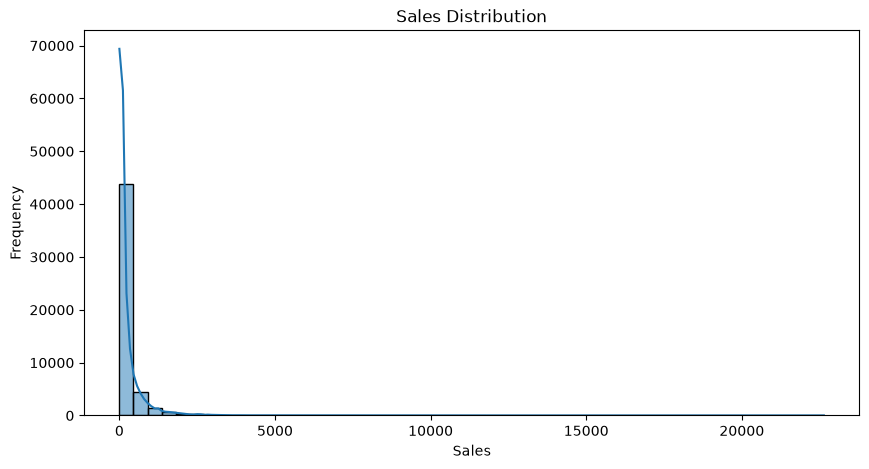

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Sales"],bins=50,kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [42]:
df["Sales"].skew()

np.float64(8.138080021220539)

In [43]:
df["Sales"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    51290.000000
mean       246.490581
std        487.565361
min          0.444000
1%           3.690000
5%           8.800000
25%         30.758625
50%         85.053000
75%        251.053200
95%       1015.955640
99%       2301.000000
max      22638.480000
Name: Sales, dtype: float64

#### 2. Profit Distribution

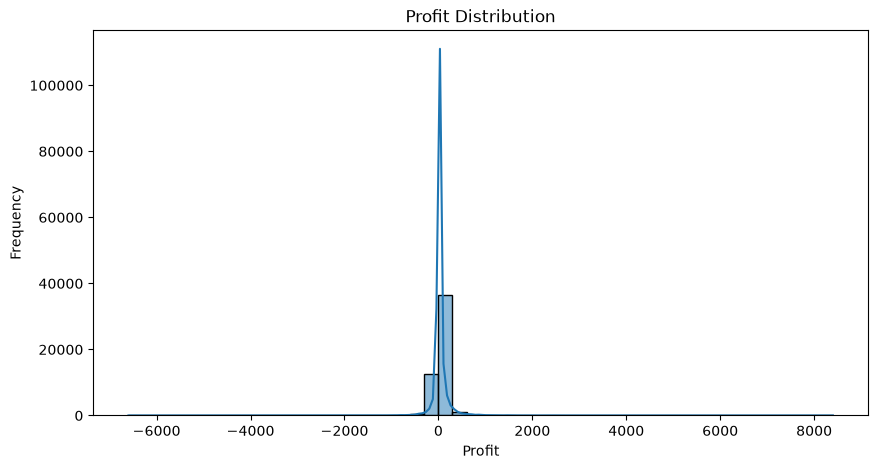

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Profit"],bins=50,kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [45]:
df["Profit"].skew()

np.float64(4.157188532777363)

In [46]:
df["Profit"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    51290.000000
mean        28.610982
std        174.340972
min      -6599.978000
1%        -351.505650
5%         -83.904750
25%          0.000000
50%          9.240000
75%         36.810000
95%        211.500000
99%        587.359950
max       8399.976000
Name: Profit, dtype: float64

#### 3. Quantity Distribution

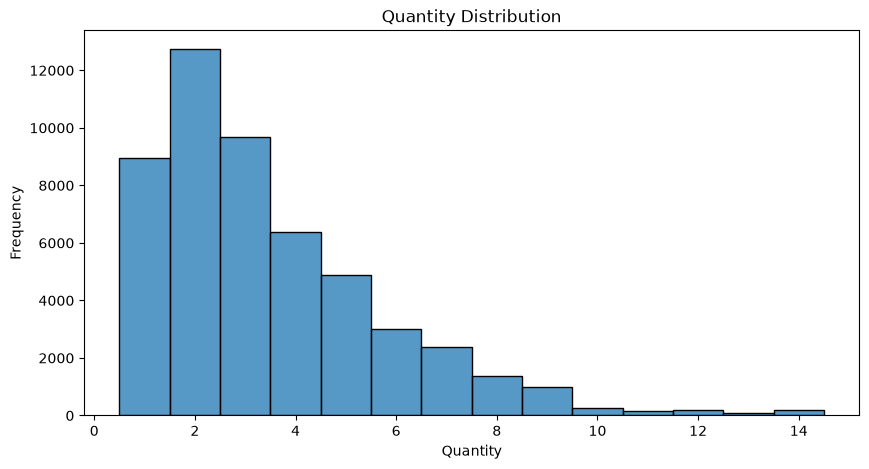

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Quantity"],bins=14,discrete=True)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

In [48]:
df["Quantity"].describe()

count    51290.000000
mean         3.476545
std          2.278766
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: Quantity, dtype: float64

In [49]:
df["Quantity"].value_counts().sort_index()

Quantity
1      8963
2     12748
3      9682
4      6385
5      4882
6      3020
7      2385
8      1361
9       987
10      276
11      156
12      176
13       83
14      186
Name: count, dtype: int64

#### 3. Discount Distribution

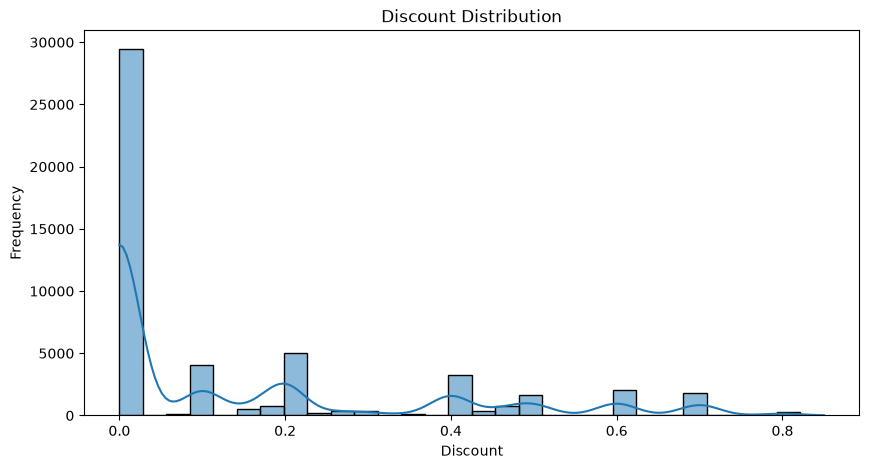

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Discount"],bins=30,kde=True)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

In [51]:
df["Discount"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
1%           0.000000
5%           0.000000
25%          0.000000
50%          0.000000
75%          0.200000
95%          0.600000
99%          0.700000
max          0.850000
Name: Discount, dtype: float64

In [52]:
df["Discount"].value_counts().sort_index()

Discount
0.000    29009
0.002      461
0.070      150
0.100     4068
0.150      459
0.150       82
0.170      735
0.200     4998
0.202       41
0.250      198
0.270      388
0.300      340
0.320       27
0.350      122
0.370       74
0.400     3177
0.402      104
0.450        2
0.450      325
0.470      725
0.500     1633
0.550       10
0.570       12
0.600     2006
0.602       23
0.650       17
0.700     1786
0.800      316
0.850        2
Name: count, dtype: int64

#### 4. Shipping Cost Distribution

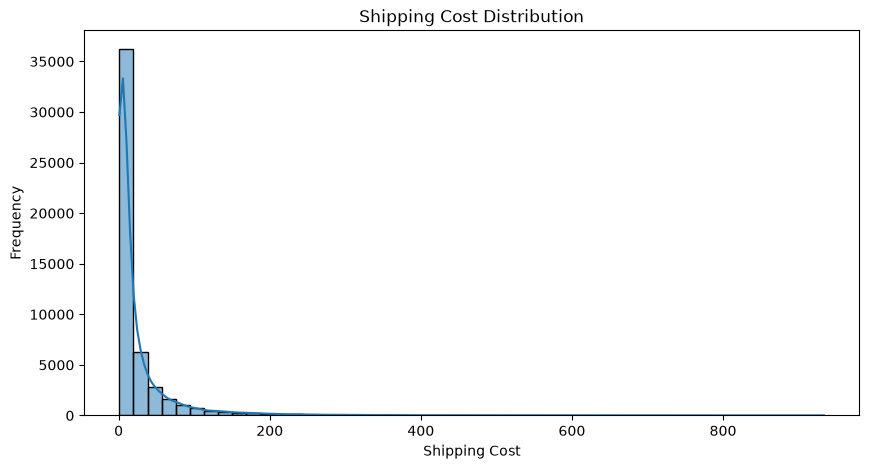

In [53]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Shipping Cost"],bins=50,kde=True)
plt.title("Shipping Cost Distribution")
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")
plt.show()

In [54]:
df["Shipping Cost"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    51290.000000
mean        26.478567
std         57.251373
min          1.002000
1%           1.110000
5%           1.320000
25%          2.610000
50%          7.790000
75%         24.450000
95%        111.409500
99%        286.754300
max        933.570000
Name: Shipping Cost, dtype: float64

In [55]:
df["Shipping Cost"].skew()

np.float64(5.872860637018438)

### Bivariate Analysis

#### 1. Discount vs Profit

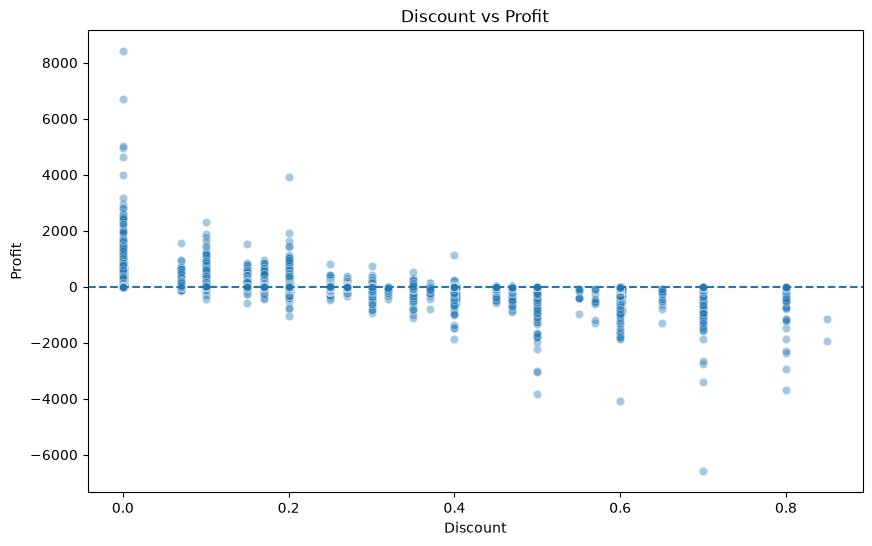

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="Discount",y="Profit",alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [57]:
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.31649
Profit,-0.31649,1.00000


In [58]:
discount_bins = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.85]
discount_labels = [
    "0-10%",
    "11-20%",
    "21-30%",
    "31-40%",
    "41-50%",
    "51-60%",
    "61-70%",
    "71-85%"]
df["Discount_Band"] = pd.cut(df["Discount"],bins=discount_bins,labels=discount_labels,include_lowest=True)
discount_profit = (df.groupby("Discount_Band", observed=False).agg(
          Transactions=("Profit", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean")))
discount_profit["Profit_Margin_%"] = (discount_profit["Total_Profit"] /discount_profit["Total_Sales"] * 100)
discount_profit

,Transactions,Total_Sales,Total_Profit,Average_Profit,Profit_Margin_%
Discount_Band,,,,,
0-10%,33688,8.955030e+06,2.108885e+06,62.600467,23.549721
11-20%,6274,1.757261e+06,1.732548e+05,27.614734,9.859367
21-30%,967,3.825547e+05,-2.115561e+04,-21.877573,-5.530089
31-40%,3400,7.013431e+05,-1.661154e+05,-48.857485,-23.685332
41-50%,2789,4.746883e+05,-2.148294e+05,-77.027382,-45.256933
51-60%,2028,1.990353e+05,-1.734189e+05,-85.512282,-87.129712
61-70%,1826,1.513292e+05,-1.974779e+05,-108.147792,-130.495580
71-85%,318,2.126017e+04,-4.168488e+04,-131.084538,-196.070301


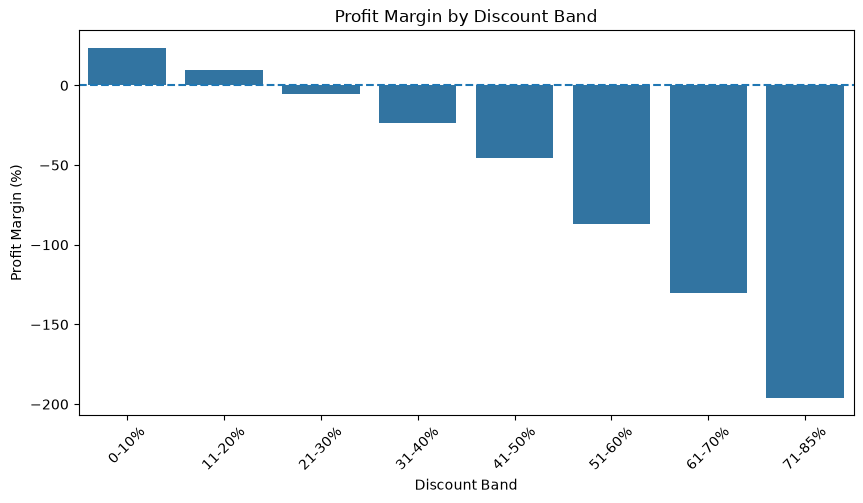

In [59]:
plt.figure(figsize=(10, 5))
sns.barplot(data=discount_profit.reset_index(),x="Discount_Band",y="Profit_Margin_%")
plt.axhline(0, linestyle="--")
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.show()

#### 2. Sales vs Profit

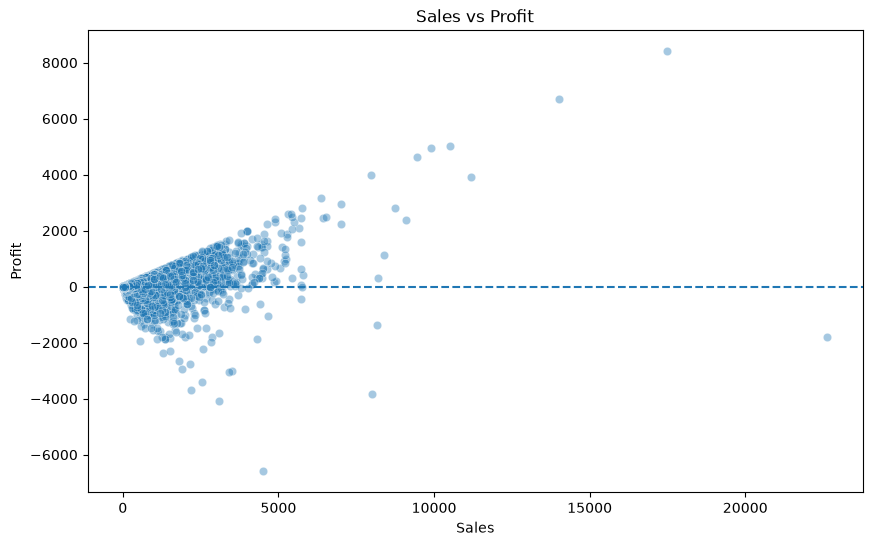

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="Sales",y="Profit",alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [61]:
df[["Sales", "Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.484918
Profit,0.484918,1.000000


In [62]:
df["Log_Sales"] = np.log1p(df["Sales"])
df[["Log_Sales", "Profit"]].corr()

,Log_Sales,Profit
Log_Sales,1.000000,0.268978
Profit,0.268978,1.000000


#### 3. Quantity vs Sales

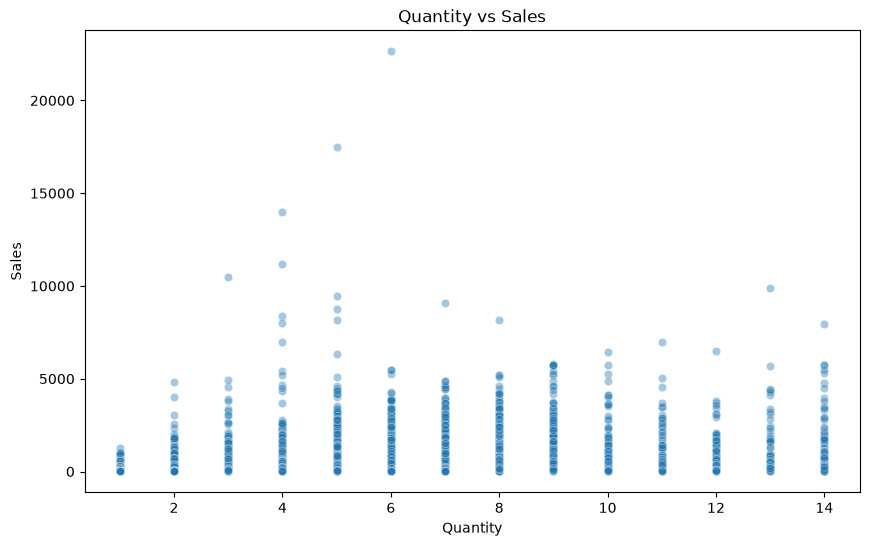

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="Quantity",y="Sales",alpha=0.4)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

In [64]:
df[["Quantity", "Sales"]].corr()

,Quantity,Sales
Quantity,1.000000,0.313577
Sales,0.313577,1.000000


In [65]:
df[["Quantity", "Log_Sales"]].corr()

,Quantity,Log_Sales
Quantity,1.000000,0.403398
Log_Sales,0.403398,1.000000


#### 4. Shipping Cost vs Profit

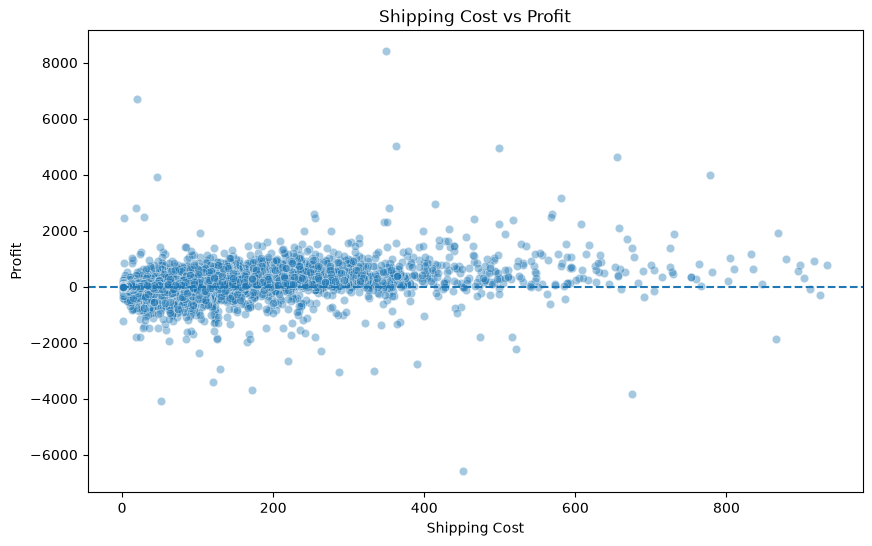

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="Shipping Cost",y="Profit",alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("Shipping Cost vs Profit")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit")
plt.show()

In [67]:
df[["Shipping Cost", "Profit"]].corr()

,Shipping Cost,Profit
Shipping Cost,1.000000,0.354423
Profit,0.354423,1.000000


In [68]:
df["Log_Shipping_Cost"] = np.log1p(df["Shipping Cost"])
df[["Log_Shipping_Cost", "Profit"]].corr()

,Log_Shipping_Cost,Profit
Log_Shipping_Cost,1.000000,0.264156
Profit,0.264156,1.000000


### Categorical EDA

#### 1. Category vs Sales & Profit

In [69]:
category_analysis = (df.groupby("Category").agg(
          Transactions=("Profit", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean")))
category_analysis["Profit_Margin_%"] = (category_analysis["Total_Profit"] /category_analysis["Total_Sales"] * 100)
category_analysis.sort_values("Total_Profit",ascending=False)

,Transactions,Total_Sales,Total_Profit,Average_Profit,Profit_Margin_%
Category,,,,,
Technology,10141,4.744557e+06,663778.73318,65.454958,13.990319
Office Supplies,31289,3.787493e+06,518595.82790,16.574382,13.692326
Furniture,9860,4.110452e+06,285082.73020,28.913056,6.935557


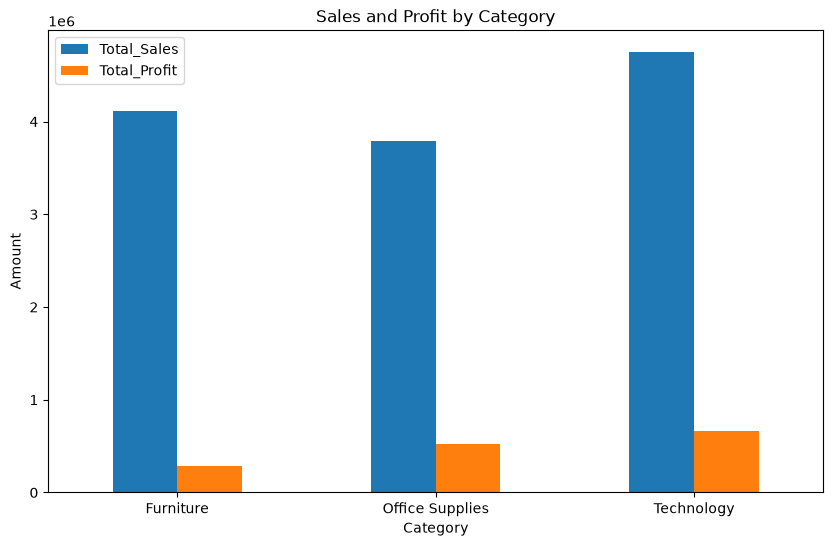

In [70]:
category_analysis[["Total_Sales", "Total_Profit"]].plot(kind="bar",figsize=(10, 6))
plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

#### 2. Customer Segment Analysis

In [71]:
segment_analysis = (df.groupby("Segment").agg(
          Transactions=("Profit", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean")))
segment_analysis["Profit_Margin_%"] = (segment_analysis["Total_Profit"] /segment_analysis["Total_Sales"] * 100)
segment_analysis.sort_values("Total_Profit",ascending=False)

,Transactions,Total_Sales,Total_Profit,Average_Profit,Profit_Margin_%
Segment,,,,,
Consumer,26518,6.507949e+06,749239.78206,28.254008,11.512686
Corporate,15429,3.824698e+06,441208.32866,28.596042,11.535771
Home Office,9343,2.309855e+06,277009.18056,29.648847,11.992492


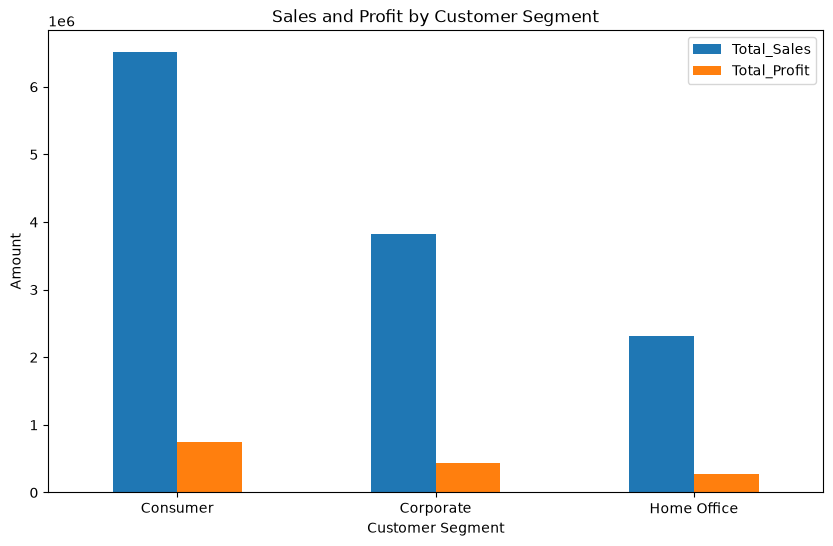

In [72]:
segment_analysis[["Total_Sales", "Total_Profit"]].plot(kind="bar",figsize=(10, 6))
plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

#### 3. Region vs Profitability

In [73]:
region_analysis = (df.groupby(["Region", "Market"]).agg(
          Transactions=("Profit", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean")))
region_analysis["Profit_Margin_%"] = (region_analysis["Total_Profit"] /region_analysis["Total_Sales"] * 100)
region_analysis.sort_values("Total_Profit",ascending=True)

,,Transactions,Total_Sales,Total_Profit,Average_Profit,Profit_Margin_%
Region,Market,,,,,
Western Asia,Asia Pacific,2440,3.171070e+05,-53921.67000,-22.099045,-17.004253
Western Africa,Africa,1460,1.738788e+05,-50407.78800,-34.525882,-28.990184
Central Asia,Asia Pacific,217,1.931146e+04,-7282.01100,-33.557654,-37.708238
Canada,USCA,384,6.692817e+04,17817.39000,46.399453,26.621660
Southeastern Asia,Asia Pacific,3129,8.844232e+05,17852.32900,5.705442,2.018528
Eastern Africa,Africa,728,1.278560e+05,21900.90900,30.083666,17.129353
Southern Africa,Africa,478,1.051918e+05,24158.55000,50.540900,22.966200
South America,LATAM,2988,6.172237e+05,28090.51788,9.401110,4.551108
Caribbean,LATAM,1690,3.242809e+05,34571.32104,20.456403,10.660919


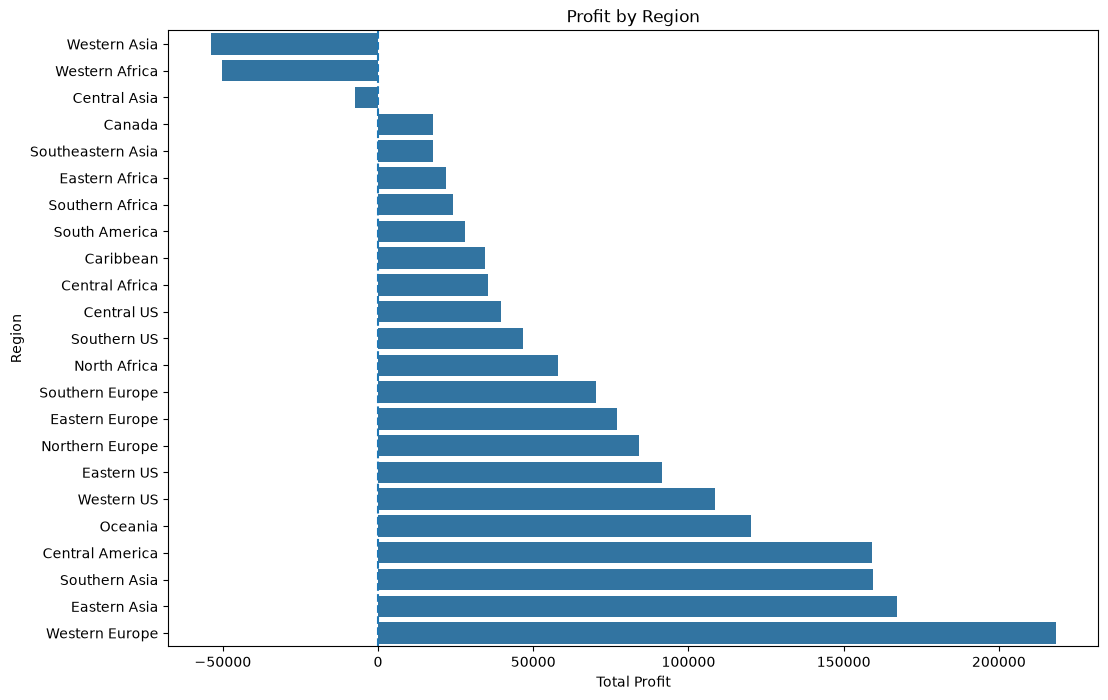

In [74]:
region_profit = (region_analysis.sort_values("Total_Profit"))
plt.figure(figsize=(12, 8))
sns.barplot(data=region_profit.reset_index(),x="Total_Profit",y="Region")
plt.axvline(0, linestyle="--")
plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")
plt.show()

#### 4. Shipping Mode Analysis

In [75]:
ship_mode_analysis = (df.groupby("Ship Mode").agg(
          Transactions=("Profit", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Shipping_Cost=("Shipping Cost", "sum"),
          Average_Profit=("Profit", "mean")))
ship_mode_analysis["Profit_Margin_%"] = (ship_mode_analysis["Total_Profit"] /ship_mode_analysis["Total_Sales"] * 100)
ship_mode_analysis["Shipping_Cost_%"] = (ship_mode_analysis["Total_Shipping_Cost"] /ship_mode_analysis["Total_Sales"] * 100)
ship_mode_analysis.sort_values("Total_Profit",ascending=False)

,Transactions,Total_Sales,Total_Profit,Total_Shipping_Cost,Average_Profit,Profit_Margin_%,Shipping_Cost_%
Ship Mode,,,,,,,
Standard Class,30775,7.578652e+06,890596.02120,618349.65550,28.938945,11.751378,8.159098
Second Class,10309,2.565672e+06,292583.52708,315009.79036,28.381368,11.403779,12.277868
First Class,7505,1.830976e+06,208104.67520,308585.54154,27.728804,11.365778,16.853608
Same Day,2701,6.672020e+05,76173.06780,116140.71600,28.201802,11.416793,17.407130


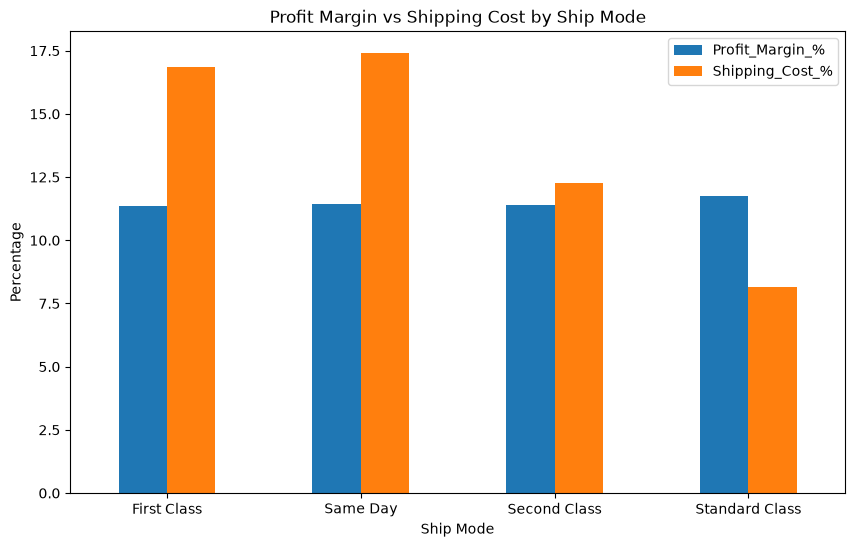

In [76]:
ship_mode_analysis[["Profit_Margin_%","Shipping_Cost_%"]].plot(kind="bar",figsize=(10, 6))
plt.title("Profit Margin vs Shipping Cost by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Outlier Analysis

#### 1. Sales outliers

In [77]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
sales_outliers = df[(df["Sales"] < lower_bound) |(df["Sales"] > upper_bound)]
print("Sales Q1:", Q1)
print("Sales Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Rows:", len(sales_outliers))

Sales Q1: 30.758625000000002
Sales Q3: 251.0532
IQR: 220.294575
Lower Bound: -299.6832375
Upper Bound: 581.4950625
Outlier Rows: 5655


In [78]:
sales_outliers[["Order ID", "Product ID", "Sales", "Quantity", "Discount", "Profit"]].sort_values("Sales", ascending=False).head(20)

,Order ID,Product ID,Sales,Quantity,Discount,Profit
47114,CA-2012-SM20320140-40985,TEC-MA-3819,22638.480,6,0.5,-1811.0784
49003,CA-2014-TC20980140-41915,TEC-CO-3691,17499.950,5,0.0,8399.9760
44248,CA-2015-RB19360140-42087,TEC-CO-3691,13999.960,4,0.0,6719.9808
49940,CA-2015-TA21385140-42300,TEC-CO-3691,11199.968,4,0.2,3919.9888
25238,CA-2015-HL15040140-42326,TEC-CO-3691,10499.970,3,0.0,5039.9856
419,CA-2014-AB10105140-41991,OFF-BI-4345,9892.740,13,0.0,4946.3700
46295,CA-2012-SC20095140-41174,OFF-BI-4821,9449.950,5,0.0,4630.4755
6422,US-2014-BS11365140-41746,TEC-MA-2865,9099.930,7,0.0,2365.9818
46386,CA-2014-SE20110140-41672,TEC-MA-4768,8749.950,5,0.0,2799.9840
11063,CA-2014-CC12370140-41783,TEC-CO-3691,8399.976,4,0.4,1119.9968


In [79]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
sales_upper_bound = Q3 + 1.5 * IQR
df["Sales_Outlier"] = (df["Sales"] > sales_upper_bound)
df["Sales_Outlier"].value_counts()

Sales_Outlier
False    45635
True      5655
Name: count, dtype: int64

#### 2. Profit Outlier Analysis

In [80]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
profit_outliers = df[(df["Profit"] < lower_bound) |(df["Profit"] > upper_bound)]
print("Profit Q1:", Q1)
print("Profit Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Rows:", len(profit_outliers))

Profit Q1: 0.0
Profit Q3: 36.81
IQR: 36.81
Lower Bound: -55.215
Upper Bound: 92.025
Outlier Rows: 9755


In [81]:
profit_outliers[[
        "Order ID",
        "Product ID",
        "Sales",
        "Quantity",
        "Discount",
        "Shipping Cost",
        "Profit"]].sort_values("Profit").head(20)

,Order ID,Product ID,Sales,Quantity,Discount,Shipping Cost,Profit
11755,CA-2014-CS12505140-41969,TEC-MA-3854,4499.985,5,0.70,451.63,-6599.9780
6591,TU-2014-DM3345134-41908,TEC-PH-5267,3085.344,12,0.60,51.89,-4088.3760
23110,US-2015-GT14635140-42313,TEC-MA-3855,7999.980,4,0.50,674.82,-3839.9904
36327,CA-2012-LF17185140-41115,OFF-BI-4340,2177.584,8,0.80,172.07,-3701.8928
47527,CA-2015-SR20425140-42112,TEC-MA-5082,2549.985,5,0.70,120.31,-3399.9800
512,IT-2014-SS20140104-41800,OFF-AP-4745,3399.660,12,0.50,286.87,-3059.8200
362,ID-2014-SN2056097-41896,TEC-PH-3148,3499.155,11,0.50,333.10,-3009.4350
24887,US-2015-HG14965140-42346,OFF-BI-4821,1889.990,5,0.80,129.51,-2929.4845
245,LH-2015-JC610575-42032,FUR-TA-3345,2171.160,8,0.70,390.09,-2750.2800
41265,CA-2013-NF18385140-41623,TEC-MA-3854,1799.994,2,0.70,219.62,-2639.9912


In [82]:
profit_outliers[[
        "Order ID",
        "Product ID",
        "Sales",
        "Quantity",
        "Discount",
        "Shipping Cost",
        "Profit"]].sort_values("Profit", ascending=False).head(20)

,Order ID,Product ID,Sales,Quantity,Discount,Shipping Cost,Profit
49003,CA-2014-TC20980140-41915,TEC-CO-3691,17499.950,5,0.0,349.07000,8399.9760
44248,CA-2015-RB19360140-42087,TEC-CO-3691,13999.960,4,0.0,20.00054,6719.9808
25238,CA-2015-HL15040140-42326,TEC-CO-3691,10499.970,3,0.0,363.19000,5039.9856
419,CA-2014-AB10105140-41991,OFF-BI-4345,9892.740,13,0.0,498.70000,4946.3700
46295,CA-2012-SC20095140-41174,OFF-BI-4821,9449.950,5,0.0,655.61000,4630.4755
17,ES-2015-PJ1883564-42255,OFF-AP-4743,7958.580,14,0.0,778.32000,3979.0800
49940,CA-2015-TA21385140-42300,TEC-CO-3691,11199.968,4,0.2,45.98000,3919.9888
11123,CA-2013-CM12385140-41349,OFF-BI-4276,6354.950,5,0.0,581.12000,3177.4750
215,ID-2012-CA1196566-40949,TEC-PH-5841,6998.640,11,0.0,413.80000,2939.3100
313,IN-2014-CA1277558-41802,TEC-PH-3149,5751.540,9,0.0,353.85000,2817.9900


#### 3. Shipping Cost Outliers

In [83]:
Q1 = df["Shipping Cost"].quantile(0.25)
Q3 = df["Shipping Cost"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
shipping_outliers = df[(df["Shipping Cost"] < lower_bound) |(df["Shipping Cost"] > upper_bound)]
print("Shipping Cost Q1:", Q1)
print("Shipping Cost Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outlier Rows:", len(shipping_outliers))

Shipping Cost Q1: 2.61
Shipping Cost Q3: 24.45
IQR: 21.84
Lower Bound: -30.15
Upper Bound: 57.209999999999994
Outlier Rows: 5909


In [84]:
shipping_outliers[[
        "Order ID",
        "Product ID",
        "Sales",
        "Quantity",
        "Discount",
        "Shipping Cost",
        "Profit",
        "Ship Mode"]].sort_values("Shipping Cost",ascending=False).head(20)

,Order ID,Product ID,Sales,Quantity,Discount,Shipping Cost,Profit,Ship Mode
44656,CA-2013-RH19495140-41486,TEC-AC-5605,2309.650,7,0.0,933.57,762.1845,Same Day
1,IN-2014-JR162107-41675,FUR-CH-5379,3709.395,9,0.1,923.63,-288.7650,Second Class
2,IN-2014-CR127307-41929,TEC-PH-5356,5175.171,9,0.1,915.49,919.9710,First Class
3,ES-2014-KM1637548-41667,TEC-PH-5267,2892.510,5,0.1,910.16,-96.5400,First Class
4,SG-2014-RH9495111-41948,TEC-CO-6011,2832.960,8,0.0,903.04,311.5200,Same Day
5,IN-2014-JM156557-41818,TEC-PH-5842,2862.675,5,0.1,897.35,763.2750,Second Class
6,IN-2012-TS2134092-41219,FUR-CH-5378,1822.080,4,0.0,894.77,564.8400,First Class
7,IN-2013-MB1808592-41378,FUR-TA-3764,5244.840,6,0.0,878.38,996.4800,Standard Class
26103,CA-2015-JW15220140-42291,OFF-BI-4276,5083.960,5,0.2,867.69,1906.4850,Standard Class
30166,CA-2013-JH15985140-41301,FUR-TA-3753,4297.644,13,0.4,865.74,-1862.3124,Second Class


### Correlation Analysis

In [85]:
correlation_matrix = df[[
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Shipping Cost",
        "Shipping_Days"]].corr()
correlation_matrix

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping_Days
Sales,1.000000,0.313577,-0.086722,0.484918,0.767835,-0.004660
Quantity,0.313577,1.000000,-0.019875,0.104365,0.271804,0.004347
Discount,-0.086722,-0.019875,1.000000,-0.316490,-0.078153,-0.001507
Profit,0.484918,0.104365,-0.316490,1.000000,0.354423,0.001745
Shipping Cost,0.767835,0.271804,-0.078153,0.354423,1.000000,-0.142551
Shipping_Days,-0.004660,0.004347,-0.001507,0.001745,-0.142551,1.000000


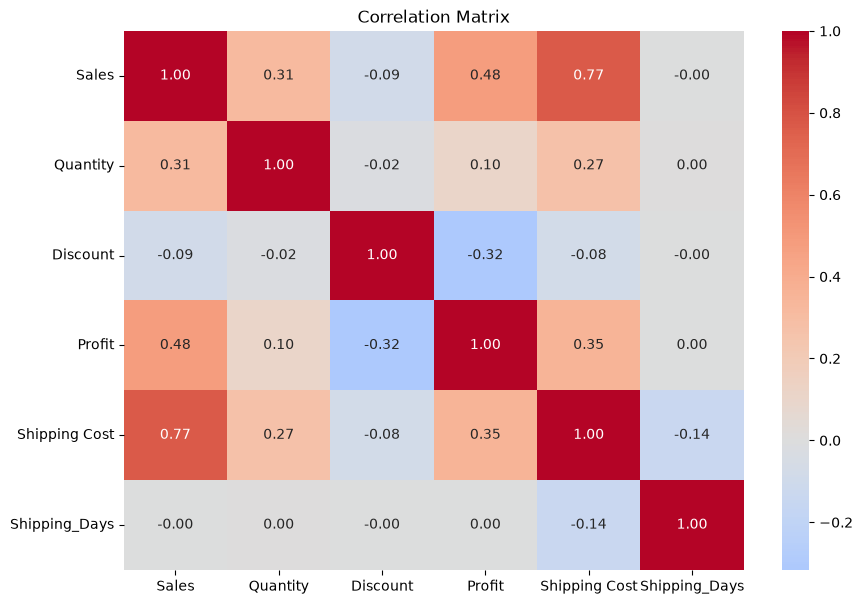

In [86]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",center=0,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Higher discounts are associated with substantially lower profitability, with profitability turning negative at higher discount levels.
- High sales do not guarantee high profit.
- Delivery duration does not appear to be a major linear determinant of sales or profitability.

### Multivariate Analysis

#### 1. Discount × Category × Profit

In [87]:
discount_category = (df.groupby(["Category", "Discount_Band"],observed=False).agg(
        Transactions=("Profit", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")))
discount_category["Profit_Margin_%"] = (discount_category["Total_Profit"]/ discount_category["Total_Sales"]* 100)
discount_category

Transactions   Total_Sales  Total_Profit  \
Category        Discount_Band                                             
Furniture       0-10%                  5562  2.600311e+06  576858.27290   
                11-20%                 1444  6.058627e+05   27963.41460   
                21-30%                  751  3.149468e+05  -19459.62280   
                31-40%                  985  3.115352e+05  -79124.72340   
                41-50%                  288  1.278067e+05  -61623.91170   
                51-60%                  565  9.968537e+04  -81173.94000   
                61-70%                  247  4.600765e+04  -67210.91540   
                71-85%                   18  4.296416e+03  -11145.84400   
Office Supplies 0-10%                 21603  2.932424e+06  696928.02500   
                11-20%                 3300  4.380743e+05   59450.23330   
                21-30%                   98  8.737903e+03    -596.53710   
                31-40%                 1685  1.451400e+05  -35454.91600   
                41-50%                 1921  1.466261e+05  -69918.28950   
                51-60%                 1147  5.086869e+04  -45525.84520   
                61-70%                 1235  4.865785e+04  -55747.80340   
                71-85%                  300  1.696376e+04  -30539.03920   
Technology      0-10%                  6523  3.422295e+06  835098.23668   
                11-20%                 1530  7.133244e+05   85841.19550   
                21-30%                  118  5.886995e+04   -1099.45322   
                31-40%                  730  2.446679e+05  -51535.80930   
                41-50%                  580  2.002555e+05  -83287.16592   
                51-60%                  316  4.848127e+04  -46719.12200   
                61-70%                  344  5.666367e+04  -74519.14856   
                71-85%                    0  0.000000e+00       0.00000   

                               Profit_Margin_%  
Category        Discount_Band                   
Furniture       0-10%                22.184203  
                11-20%                4.615471  
                21-30%               -6.178701  
                31-40%              -25.398327  
                41-50%              -48.216479  
                51-60%              -81.430145  
                61-70%             -146.086404  
                71-85%             -259.421900  
Office Supplies 0-10%                23.766278  
                11-20%               13.570811  
                21-30%               -6.827005  
                31-40%              -24.428076  
                41-50%              -47.684753  
                51-60%              -89.496788  
                61-70%             -114.571047  
                71-85%             -180.025221  
Technology      0-10%                24.401703  
                11-20%               12.033964  
                21-30%               -1.867597  
                31-40%              -21.063574  
                41-50%              -41.590457  
                51-60%              -96.365305  
                61-70%             -131.511336  
                71-85%                     NaN

In [88]:
discount_category["Profit_Margin_%"].unstack("Discount_Band")

Discount_Band,0-10%,11-20%,21-30%,31-40%,41-50%,51-60%,61-70%,71-85%
Category,,,,,,,,
Furniture,22.184203,4.615471,-6.178701,-25.398327,-48.216479,-81.430145,-146.086404,-259.421900
Office Supplies,23.766278,13.570811,-6.827005,-24.428076,-47.684753,-89.496788,-114.571047,-180.025221
Technology,24.401703,12.033964,-1.867597,-21.063574,-41.590457,-96.365305,-131.511336,NaN


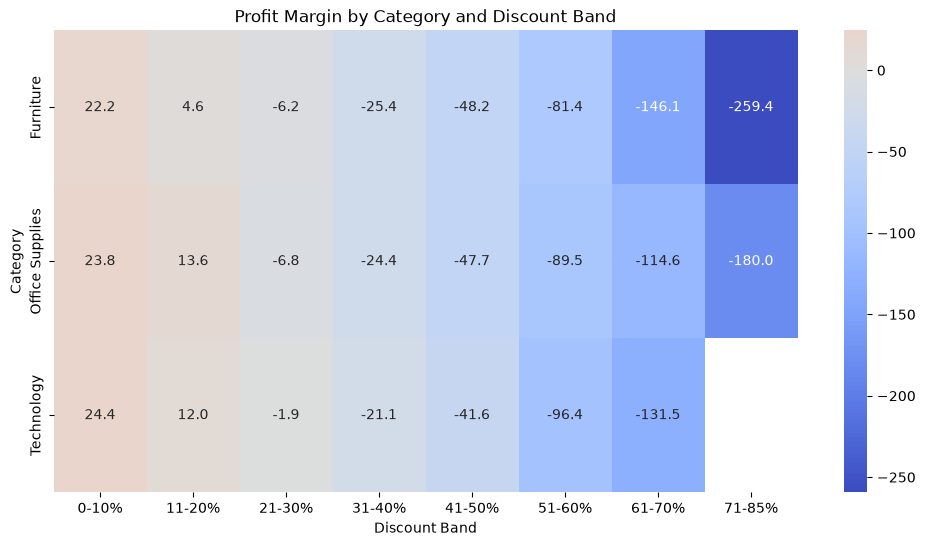

In [89]:
plt.figure(figsize=(12, 6))
sns.heatmap(discount_category["Profit_Margin_%"].unstack("Discount_Band"),annot=True,fmt=".1f",center=0,cmap="coolwarm")
plt.title("Profit Margin by Category and Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Category")
plt.show()

The negative impact of aggressive discounting is consistent across all product categories, but the magnitude differs by category. Furniture is the most discount-sensitive, while Technology remains comparatively resilient at moderate discount levels.

#### 2. Discount × Region × Profit

In [90]:
discount_region = (df.groupby(["Region", "Discount_Band"],observed=False).agg(
        Transactions=("Profit", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")))
discount_region["Profit_Margin_%"] = (discount_region["Total_Profit"]/ discount_region["Total_Sales"]* 100)
discount_region.sort_values("Total_Profit").head(20)

,,Transactions,Total_Sales,Total_Profit,Profit_Margin_%
Region,Discount_Band,,,,
Western Asia,51-60%,1378,108507.94800,-98447.23200,-90.728130
Western Africa,61-70%,905,54350.35200,-80750.71800,-148.574416
Western Europe,41-50%,528,90359.62350,-50203.30650,-55.559446
Southeastern Asia,41-50%,1039,108791.88990,-41172.74010,-37.845413
Central America,31-40%,1191,130901.05200,-36907.56800,-28.195013
Oceania,31-40%,712,135209.50200,-36457.66800,-26.963836
South America,51-60%,356,39291.04000,-36226.94000,-92.201530
Northern Europe,41-50%,471,70433.04000,-33017.25000,-46.877502
Central US,71-85%,300,16963.75600,-30539.03920,-180.025221


In [91]:
discount_region.sort_values("Profit_Margin_%").head(20)

,,Transactions,Total_Sales,Total_Profit,Profit_Margin_%
Region,Discount_Band,,,,
Western Europe,71-85%,2,796.84200,-3068.65800,-385.102442
Northern Europe,71-85%,4,158.91600,-460.28400,-289.639810
Southern Asia,71-85%,7,2240.00400,-5338.80600,-238.339128
South America,71-85%,1,38.14400,-87.73600,-230.012584
Eastern Asia,71-85%,4,1062.51000,-2190.36000,-206.149589
Central US,71-85%,300,16963.75600,-30539.03920,-180.025221
Central Asia,61-70%,129,6875.28900,-10665.47100,-155.127603
Caribbean,61-70%,40,6264.65400,-9585.64600,-153.011579
Western Africa,61-70%,905,54350.35200,-80750.71800,-148.574416


Regional profitability problems are strongly concentrated in high-discount transactions. The largest regional losses occur in discount bands above 40%, indicating that regional performance and discount strategy should be evaluated together rather than independently.

### Product Profitability Matrix

In [92]:
product_analysis = (df.groupby(["Product ID", "Product Name", "Category", "Sub-Category"]).agg(
        Total_Quantity=("Quantity", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")))
product_analysis["Profit_Margin_%"] = (product_analysis["Total_Profit"]/ product_analysis["Total_Sales"]* 100)
product_analysis.head()

,,,,Total_Quantity,Total_Sales,Total_Profit,Profit_Margin_%
Product ID,Product Name,Category,Sub-Category,,,,
FUR-BO-3174,"Atlantic Metals Mobile 2-Shelf Bookcases, Custom Colors",Furniture,Bookcases,3,400.0268,-113.2606,-28.313253
FUR-BO-3175,"Atlantic Metals Mobile 3-Shelf Bookcases, Custom Colors",Furniture,Bookcases,35,7539.7122,780.3302,10.349602
FUR-BO-3176,"Atlantic Metals Mobile 4-Shelf Bookcases, Custom Colors",Furniture,Bookcases,27,5184.0810,-126.4410,-2.439024
FUR-BO-3177,"Atlantic Metals Mobile 5-Shelf Bookcases, Custom Colors",Furniture,Bookcases,26,5492.8850,15.0490,0.273973
FUR-BO-3409,Bestar Classic Bookcase,Furniture,Bookcases,31,1897.8102,-612.9387,-32.297155


In [93]:
sales_median = product_analysis["Total_Sales"].median()
profit_median = product_analysis["Total_Profit"].median()
print("Sales Median:", sales_median)
print("Profit Median:", profit_median)

Sales Median: 1268.809
Profit Median: 97.04799999999997


In [94]:
def classify_product(row):
    if row["Total_Sales"] >= sales_median and row["Total_Profit"] >= profit_median:
        return "Strong Products"
    elif row["Total_Sales"] >= sales_median and row["Total_Profit"] < profit_median:
        return "Problem Products"
    elif row["Total_Sales"] < sales_median and row["Total_Profit"] >= profit_median:
        return "Hidden Opportunities"
    else:
        return "Weak Products"
product_analysis["Product_Segment"] = (product_analysis.apply(classify_product, axis=1))
product_analysis["Product_Segment"].value_counts()

Product_Segment
Weak Products           1371
Strong Products         1371
Problem Products         523
Hidden Opportunities     523
Name: count, dtype: int64

In [95]:
product_analysis[product_analysis["Product_Segment"] == "Strong Products"].sort_values("Total_Profit",ascending=False).head(10)

,,,,Total_Quantity,Total_Sales,Total_Profit,Profit_Margin_%,Product_Segment
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-CO-3691,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,20,61599.8240,25199.9280,40.909091,Strong Products
TEC-PH-3806,"Cisco Smart Phone, Full Size",Technology,Phones,139,76441.5306,17238.5206,22.551250,Strong Products
TEC-PH-5268,"Motorola Smart Phone, Full Size",Technology,Phones,134,73156.3030,17027.1130,23.274977,Strong Products
OFF-AP-4743,"Hoover Stove, Red",Office Supplies,Appliances,62,31663.7790,11807.9690,37.291724,Strong Products
FUR-BO-5951,"Sauder Classic Bookcase, Traditional",Furniture,Bookcases,113,39108.3030,10672.0730,27.288510,Strong Products
FUR-CH-4530,"Harbour Creations Executive Leather Armchair, Adjustable",Furniture,Chairs,142,50121.5160,10427.3260,20.804091,Strong Products
TEC-PH-5355,"Nokia Smart Phone, Full Size",Technology,Phones,147,71904.5555,9938.1955,13.821371,Strong Products
TEC-PH-3807,"Cisco Smart Phone, with Caller ID",Technology,Phones,85,43127.5008,9786.6408,22.692344,Strong Products
TEC-PH-5356,"Nokia Smart Phone, with Caller ID",Technology,Phones,96,47877.7857,9465.3257,19.769765,Strong Products


In [96]:
product_analysis[product_analysis["Product_Segment"] == "Problem Products"].sort_values("Total_Profit").head(10)

,,,,Total_Quantity,Total_Sales,Total_Profit,Profit_Margin_%,Product_Segment
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-MA-3854,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,9,11099.9630,-8879.9704,-80.000000,Problem Products
TEC-MA-5082,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,18,16829.9010,-4589.9730,-27.272727,Problem Products
TEC-PH-5267,"Motorola Smart Phone, Cordless",Technology,Phones,74,38931.0420,-4447.0380,-11.422859,Problem Products
TEC-MA-3855,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,4,7999.9800,-3839.9904,-48.000000,Problem Products
FUR-TA-3429,"Bevis Round Table, Adjustable Height",Furniture,Tables,22,5654.7960,-3649.8940,-64.545105,Problem Products
FUR-TA-3418,"Bevis Computer Table, Fully Assembled",Furniture,Tables,43,11177.8962,-3509.5638,-31.397355,Problem Products
OFF-ST-5700,"Rogers Lockers, Blue",Office Supplies,Storage,167,28214.5892,-2893.4908,-10.255300,Problem Products
FUR-TA-3753,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,Furniture,Tables,27,9917.6400,-2876.1156,-29.000000,Problem Products
FUR-TA-3442,"Bevis Wood Table, with Bottom Storage",Furniture,Tables,34,11134.6620,-2782.5880,-24.990323,Problem Products


In [97]:
product_analysis[product_analysis["Product_Segment"] == "Hidden Opportunities"].sort_values("Total_Profit",ascending=False).head(10)

,,,,Total_Quantity,Total_Sales,Total_Profit,Profit_Margin_%,Product_Segment
Product ID,Product Name,Category,Sub-Category,,,,,
OFF-PA-6469,Xerox 1917,Office Supplies,Paper,25,1222.750,574.6925,47.000000,Hidden Opportunities
OFF-EN-6327,Tyvek Side-Opening Peel & Seel Expanding Envelopes,Office Supplies,Envelopes,14,1266.720,570.0240,45.000000,Hidden Opportunities
OFF-PA-6437,Xerox 1888,Office Supplies,Paper,24,1231.656,539.2656,43.783784,Hidden Opportunities
OFF-PA-6488,Xerox 1934,Office Supplies,Paper,20,1097.208,526.2120,47.959184,Hidden Opportunities
OFF-LA-3190,"Avery 4027 File Folder Labels for Dot Matrix Printers, 5000 Labels per Box, White",Office Supplies,Labels,43,1233.412,524.5054,42.524752,Hidden Opportunities
TEC-AC-5147,Logitech Illuminated - Keyboard,Technology,Accessories,20,1139.810,515.9140,45.263158,Hidden Opportunities
OFF-PA-6457,Xerox 1906,Office Supplies,Paper,32,1098.640,497.5776,45.290323,Hidden Opportunities
OFF-PA-4009,"Eaton Premium Continuous-Feed Paper, 25% Cotton, Letter Size, White, 1000 Shts/Box",Office Supplies,Paper,21,1098.504,492.6624,44.848485,Hidden Opportunities
OFF-PA-3998,"Eaton Message Books, 8.5 x 11",Office Supplies,Paper,61,1261.544,465.3140,36.884484,Hidden Opportunities


In [98]:
product_analysis[product_analysis["Product_Segment"] == "Weak Products"].sort_values("Total_Profit").head(10)

,,,,Total_Quantity,Total_Sales,Total_Profit,Profit_Margin_%,Product_Segment
Product ID,Product Name,Category,Sub-Category,,,,,
FUR-TA-3756,"Chromcraft Coffee Table, Fully Assembled",Furniture,Tables,19,1226.424,-1960.6960,-159.870974,Weak Products
TEC-MA-4213,Epson TM-T88V Direct Thermal Printer - Monochrome - Desktop,Technology,Machines,10,1212.705,-1057.2300,-87.179487,Weak Products
TEC-MA-6630,Zebra GK420t Direct Thermal/Thermal Transfer Printer,Technology,Machines,6,703.710,-938.2800,-133.333333,Weak Products
FUR-TA-3424,Bevis Rectangular Conference Tables,Furniture,Tables,13,1007.262,-586.8396,-58.260870,Weak Products
TEC-MA-5081,Lexmark MarkNet N8150 Wireless Print Server,Technology,Machines,6,723.510,-506.4570,-70.000000,Weak Products
FUR-TA-3438,"Bevis Training Table, with Bottom Storage",Furniture,Tables,5,669.960,-482.4600,-72.013255,Weak Products
FUR-TA-5051,"Lesro Coffee Table, Fully Assembled",Furniture,Tables,11,1115.268,-474.1620,-42.515521,Weak Products
FUR-BO-5963,"Sauder Forest Hills Library with Doors, Woodland Oak Finish",Furniture,Bookcases,10,1014.174,-418.5480,-41.269841,Weak Products
FUR-TA-5684,Riverside Furniture Stanwyck Manor Table Series,Furniture,Tables,5,917.920,-415.9325,-45.312500,Weak Products


# ML Target

In [99]:
df["Is_Loss"] = (df["Profit"] < 0).astype(int)

In [100]:
df["Is_Loss"].value_counts()

Is_Loss
0    38746
1    12544
Name: count, dtype: int64

In [101]:
df["Is_Loss"].value_counts(normalize=True) * 100

Is_Loss
0    75.542991
1    24.457009
Name: proportion, dtype: float64

0 → Profitable transaction, 
1 → Loss-making transaction

# Feature Selection

Numerical features:

- Sales
- Quantity
- Discount
- Shipping Cost
- Shipping Days

Categorical features :

- Category
- Sub-Category
- Segment
- Region
- Market
- Ship Mode
- Order Priority

Date features :

In [102]:
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek

Features we should NOT use :

- Profit        ← target leakage
- Is_Loss       ← target
- Row ID        ← identifier
- Order ID      ← identifier
- Customer Name ← high-cardinality identifier
- Product Name  ← high-cardinality text

# Data Splitting

In [103]:
df["Is_Loss"] = (df["Profit"] < 0).astype(int)
df["Is_Loss"].value_counts()

Is_Loss
0    38746
1    12544
Name: count, dtype: int64

In [104]:
df["Is_Loss"].value_counts(normalize=True) * 100

Is_Loss
0    75.542991
1    24.457009
Name: proportion, dtype: float64

In [105]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Cost",
    "Shipping_Days",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Market",
    "Ship Mode",
    "Order Priority"]
X = df[features].copy()
y = df["Is_Loss"].copy()
X.shape, y.shape

((51290, 12), (51290,))

In [106]:
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek

In [107]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Cost",
    "Shipping_Days",
    "Order_Year",
    "Order_Month",
    "Order_DayOfWeek",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Market",
    "Ship Mode",
    "Order Priority"]
X = df[features].copy()
y = df["Is_Loss"].copy()

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (41032, 15)
Testing set : (10258, 15)


# Pre-Preprocessing

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [110]:
numeric_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Cost",
    "Shipping_Days",
    "Order_Year",
    "Order_Month",
    "Order_DayOfWeek"]
categorical_features = [
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Market",
    "Ship Mode",
    "Order Priority"]
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),("cat", categorical_pipeline, categorical_features)])

# Model Trail

### Logistic Regression

In [111]:
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000,random_state=42))])
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Sales','Quantity','Discount',...,'Market','Ship Mode','Order Priority']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [112]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [113]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9269838175082862
Precision: 0.8963963963963963
Recall   : 0.7931446791550418
F1 Score : 0.8416155635440896
ROC-AUC  : 0.975423923610452

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7749
           1       0.90      0.79      0.84      2509

    accuracy                           0.93     10258
   macro avg       0.92      0.88      0.90     10258
weighted avg       0.93      0.93      0.93     10258



In [114]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7519  230]
 [ 519 1990]]


### Decision Tree

In [115]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeClassifier(random_state=42,max_depth=10, min_samples_split=10,
                                                                                                min_samples_leaf=5))])
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Sales','Quantity','Discount',...,'Market','Ship Mode','Order Priority']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [116]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [117]:
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.9249366348216026
Precision: 0.8876504681230495
Recall   : 0.7935432443204464
F1 Score : 0.8379629629629629
ROC-AUC  : 0.9679801829429026

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7749
           1       0.89      0.79      0.84      2509

    accuracy                           0.92     10258
   macro avg       0.91      0.88      0.89     10258
weighted avg       0.92      0.92      0.92     10258



In [118]:
confusion_matrix(y_test, y_pred_dt)

array([[7497,  252],
       [ 518, 1991]])

Logistic Regression remains the better model overall because it has higher F1 and ROC-AUC, while the Decision Tree provides almost no meaningful improvement in detecting losses

### Random Forest

In [119]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([("preprocessor", preprocessor),("model", RandomForestClassifier(n_estimators=200,max_depth=12,min_samples_split=10,
                                                                                                min_samples_leaf=5,random_state=42,n_jobs=-1))])
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Sales','Quantity','Discount',...,'Market','Ship Mode','Order Priority']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [120]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [121]:
print("Random Forest Results")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
--------------------
Accuracy : 0.9285435757457594
Precision: 0.909972299168975
Recall   : 0.7855719410123555
F1 Score : 0.8432085561497327
ROC-AUC  : 0.9755385194535959

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7749
           1       0.91      0.79      0.84      2509

    accuracy                           0.93     10258
   macro avg       0.92      0.88      0.90     10258
weighted avg       0.93      0.93      0.93     10258



In [122]:
confusion_matrix(y_test, y_pred_rf)

array([[7554,  195],
       [ 538, 1971]])

### Gradient Boosting

In [123]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_model = Pipeline([("preprocessor", preprocessor),("model", GradientBoostingClassifier(n_estimators=150,learning_rate=0.05,
        max_depth=3,random_state=42))])
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Sales','Quantity','Discount',...,'Market','Ship Mode','Order Priority']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [124]:
y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [125]:
print("Gradient Boosting Results")
print("------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
------------------------
Accuracy : 0.9277636966270228
Precision: 0.9003623188405797
Recall   : 0.7923475488242328
F1 Score : 0.8429086283654865
ROC-AUC  : 0.9779748383944012

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7749
           1       0.90      0.79      0.84      2509

    accuracy                           0.93     10258
   macro avg       0.92      0.88      0.90     10258
weighted avg       0.93      0.93      0.93     10258



In [126]:
confusion_matrix(y_test, y_pred_gb)

array([[7529,  220],
       [ 521, 1988]])

# Tune the classification threshold

### Gradient Boosting

In [127]:
import numpy as np
from sklearn.metrics import precision_recall_curve
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
for threshold in thresholds:
    y_pred_threshold = (y_prob_gb >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1 Score :", f1_score(y_test, y_pred_threshold))
    print("False Negatives:",confusion_matrix(y_test, y_pred_threshold)[1, 0])


Threshold: 0.3
Precision: 0.8064516129032258
Recall   : 0.8768433638899961
F1 Score : 0.8401756730952835
False Negatives: 309

Threshold: 0.35
Precision: 0.8425414364640884
Recall   : 0.8509366281387006
F1 Score : 0.8467182232797937
False Negatives: 374

Threshold: 0.4
Precision: 0.8661417322834646
Recall   : 0.8330011956954962
F1 Score : 0.8492482730597318
False Negatives: 419

Threshold: 0.45
Precision: 0.8897188049209139
Recall   : 0.8070944599442009
F1 Score : 0.8463949843260188
False Negatives: 484

Threshold: 0.5
Precision: 0.9003623188405797
Recall   : 0.7923475488242328
F1 Score : 0.8429086283654865
False Negatives: 521


In [128]:
final_threshold = 0.40
y_pred_final = (y_prob_gb >= final_threshold).astype(int)

In [129]:
print("Final Gradient Boosting Model")
print("-----------------------------")
print("Threshold:", final_threshold)
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Gradient Boosting Model
-----------------------------
Threshold: 0.4
Accuracy : 0.9276662117371808
Precision: 0.8661417322834646
Recall   : 0.8330011956954962
F1 Score : 0.8492482730597318

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7749
           1       0.87      0.83      0.85      2509

    accuracy                           0.93     10258
   macro avg       0.91      0.90      0.90     10258
weighted avg       0.93      0.93      0.93     10258


Confusion Matrix:
[[7426  323]
 [ 419 2090]]


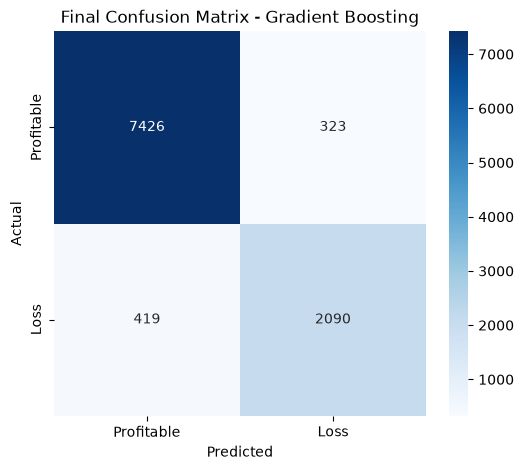

In [130]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final),annot=True,fmt="d",cmap="Blues",xticklabels=["Profitable", "Loss"],
            yticklabels=["Profitable", "Loss"])
plt.title("Final Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Gradient Boosting with a 0.40 classification threshold provides the best balance between identifying loss-making transactions and avoiding excessive false alarms among the tested thresholds.

## Model Interpretation

In [131]:
from sklearn.inspection import permutation_importance
# Transform the test data using the fitted preprocessing pipeline
X_test_transformed = gradient_boosting_model.named_steps["preprocessor"].transform(X_test)
# Get feature names
feature_names = (gradient_boosting_model.named_steps["preprocessor"].get_feature_names_out())
# Get the trained model
gb_model = gradient_boosting_model.named_steps["model"]
# Feature importance
importance = pd.Series(gb_model.feature_importances_,index=feature_names).sort_values(ascending=False)
importance.head(20)

num__Discount                    0.973035
cat__Market_USCA                 0.010976
cat__Sub-Category_Storage        0.004005
num__Sales                       0.003365
cat__Region_Southeastern Asia    0.002449
cat__Market_LATAM                0.002053
num__Shipping Cost               0.000835
cat__Sub-Category_Binders        0.000678
cat__Sub-Category_Paper          0.000604
cat__Region_Western US           0.000296
cat__Region_Southern Europe      0.000229
cat__Sub-Category_Chairs         0.000225
cat__Category_Furniture          0.000184
cat__Sub-Category_Supplies       0.000150
cat__Category_Office Supplies    0.000103
num__Shipping_Days               0.000091
cat__Market_Asia Pacific         0.000085
cat__Sub-Category_Bookcases      0.000070
cat__Sub-Category_Accessories    0.000067
num__Order_Month                 0.000062
dtype: float64

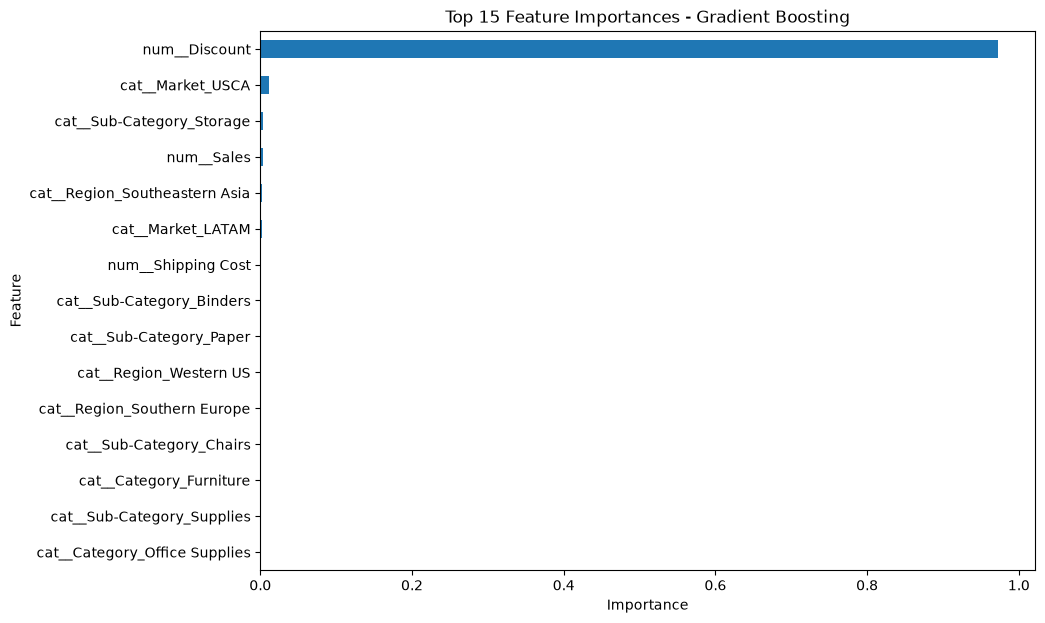

In [132]:
plt.figure(figsize=(10, 7))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [133]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(gradient_boosting_model,X_test,y_test,scoring="f1",n_repeats=5,random_state=42,n_jobs=-1)
perm_df = pd.DataFrame({"Feature": X_test.columns,"Importance_Mean": perm_importance.importances_mean,"Importance_Std": perm_importance.importances_std
                       }).sort_values("Importance_Mean",ascending=False)
perm_df

,Feature,Importance_Mean,Importance_Std
2,Discount,0.611955,0.007710
12,Market,0.000481,0.000815
3,Shipping Cost,0.000469,0.000613
13,Ship Mode,0.000437,0.000270
8,Category,0.000276,0.000529
5,Order_Year,0.000268,0.000176
7,Order_DayOfWeek,0.000205,0.000447
14,Order Priority,0.000022,0.000082
10,Segment,0.000000,0.000000
6,Order_Month,0.000000,0.000000


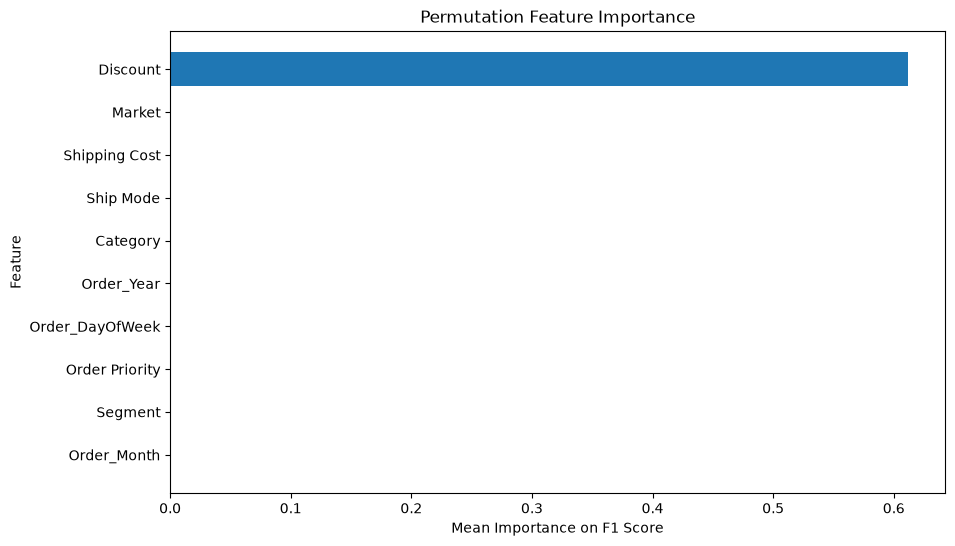

In [134]:
plt.figure(figsize=(10, 6))
top_perm = perm_df.head(10).sort_values("Importance_Mean")
plt.barh(top_perm["Feature"],top_perm["Importance_Mean"])
plt.title("Permutation Feature Importance")
plt.xlabel("Mean Importance on F1 Score")
plt.ylabel("Feature")
plt.show()

## ML Prediction Table

In [135]:
ml_risk = df.loc[X_test.index, [
    "Order ID",
    "Product ID",
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Cost",
    "Category",
    "Sub-Category",
    "Region"]].copy()
ml_risk["Predicted_Loss_Probability"] = y_prob_gb
ml_risk["Predicted_Loss"] = (y_prob_gb >= 0.40).astype(int)
ml_risk["Risk_Level"] = pd.cut(ml_risk["Predicted_Loss_Probability"],bins=[0, 0.30, 0.40, 0.60, 1.00],labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"],include_lowest=True)
ml_risk.head()

,Order ID,Product ID,Sales,Quantity,Discount,Shipping Cost,Category,Sub-Category,Region,Predicted_Loss_Probability,Predicted_Loss,Risk_Level
14990,MZ-2013-CM238587-41287,TEC-AC-5866,82.980,1,0.0,19.75,Technology,Accessories,Eastern Africa,0.001758,0,Low Risk
42993,TU-2014-AW840134-41956,OFF-FA-6205,10.056,2,0.6,1.86,Office Supplies,Fasteners,Western Asia,0.993986,1,Very High Risk
50836,CA-2015-VW21775140-42047,OFF-BI-2923,21.336,7,0.2,1.20,Office Supplies,Binders,Western US,0.055462,0,Low Risk
34330,IN-2013-AB101057-41626,OFF-ST-6038,62.964,4,0.1,3.80,Office Supplies,Storage,Oceania,0.232967,0,Low Risk
43818,HU-2015-AR40557-42147,OFF-AR-5923,29.010,1,0.0,1.78,Office Supplies,Art,Eastern Europe,0.001715,0,Low Risk


In [136]:
print("Prediction rows:", len(ml_risk))
print(ml_risk["Risk_Level"].value_counts())
print(ml_risk["Predicted_Loss"].value_counts())

Prediction rows: 10258
Risk_Level
Low Risk          7530
Very High Risk    2121
Moderate Risk      315
High Risk          292
Name: count, dtype: int64
Predicted_Loss
0    7845
1    2413
Name: count, dtype: int64


In [138]:
ml_risk.to_csv(r"C:\Users\hp\OneDrive\Desktop\Retail-Analytics-Platform\Data\Prediction_table.xls",index=False)
print("ML_Loss_Risk.csv created successfully")

ML_Loss_Risk.csv created successfully


## Model Deployment

In [144]:
import joblib
import os
model_path = r"C:\Users\hp\OneDrive\Desktop\Retail-Analytics-Platform\Model_Deployment\gradient_boosting_loss_model.pkl"
joblib.dump(gradient_boosting_model,model_path)
print("Saved successfully")
print("File size:", os.path.getsize(model_path), "bytes")

Saved successfully
File size: 213421 bytes


In [145]:
feature_config = {
    "numeric_features": [
        "Sales",
        "Quantity",
        "Discount",
        "Shipping Cost",
        "Shipping_Days",
        "Order_Year",
        "Order_Month",
        "Order_DayOfWeek"], 
    "categorical_features": [
        "Category",
        "Sub-Category",
        "Segment",
        "Region",
        "Market",
        "Ship Mode",
        "Order Priority"],
    "threshold": 0.40}
config_path = r"C:\Users\hp\OneDrive\Desktop\Retail-Analytics-Platform\Model_Deployment\feature_config.pkl"
joblib.dump(feature_config, config_path)
print("Configuration saved")
print("File size:", os.path.getsize(config_path), "bytes")

Configuration saved
File size: 277 bytes


#### Testing Model

In [146]:
loaded_model = joblib.load(model_path)
print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [147]:
sample = X_test.iloc[[0]]
probability = loaded_model.predict_proba(sample)[0, 1]
print("Loss probability:", probability)
print("Prediction:", int(probability >= 0.40))

Loss probability: 0.001758019697758638
Prediction: 0


0 → Profitable

1 → Loss-making